## Mimic III Sepsis Data Baseline Models

### 1. Objective
* Use mimic III sepsis data to train baseline models that predict 90-day mortality using all the varaibles except other outcome variables ("died_in_hosp", "died_within_48h_of_out_time"), and "reward", "icustayid", "charttime", "bloc".
* Because the response is a binary variable, the baseline models will be logistic lasso, logistic ridge, random forest classifier and neural network classifier.

### 2. Load and Preprocess Data

In [21]:
import pandas as pd

df = pd.read_csv("../data/mimic3_sepsis_data.csv")

In [22]:
# Define the response variable and columns to drop
response = "mortality_90d"
drop_cols = [
    "mortality_90d",                  # response
    "died_in_hosp",                   # another outcome
    "died_within_48h_of_out_time",    # another outcome
    "reward",                         # RL reward
    "icustayid",                      # patient ID
    "charttime",                      # timestamp
    "bloc",                         # constant (=1)
    "delay_end_of_record_and_discharge_or_death" # another outcome
]

X = df.drop(columns=drop_cols)
Y = df[response]

In [23]:
# Check if there are null values
print(X.isnull().sum().sort_values(ascending=False).head(20))

gender              0
mechvent            0
WBC_count           0
Platelets_count     0
PTT                 0
PT                  0
INR                 0
Arterial_pH         0
paO2                0
paCO2               0
Arterial_BE         0
Arterial_lactate    0
HCO3                0
Shock_Index         0
age                 0
PaO2_FiO2           0
median_dose_vaso    0
max_dose_vaso       0
input_total         0
input_4hourly       0
dtype: int64


In [24]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [25]:
# Check the shapes of the datasets
print(X_train.shape)
print(X_test.shape)

# Check the distribution of the response variable
print(Y_train.value_counts(normalize=True))
print(Y_test.value_counts(normalize=True))

(16764, 54)
(4191, 54)
mortality_90d
0    0.765629
1    0.234371
Name: proportion, dtype: float64
mortality_90d
0    0.765688
1    0.234312
Name: proportion, dtype: float64


### 3. Logistic Lasso

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# standardize the predictors
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Baseline

In [27]:
from sklearn.linear_model import LogisticRegression
import time

lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",   
    C=1.0,                
    random_state=42,
    max_iter=1000
)

start1 = time.perf_counter()

lasso.fit(X_train, Y_train)

runtime1 = time.perf_counter() - start1

y_prob = lasso.predict_proba(X_test)[:, 1]
y_pred = lasso.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(Y_test, y_pred)
auc = roc_auc_score(Y_test, y_prob)
precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)
print("runtime: "+ str(runtime1))
print("accuracy: "+ str(accuracy))
print("AUC: "+ str(auc))
print("precision: "+ str(precision))
print("recall: "+ str(recall))
print("F1: "+ str(f1))

runtime: 1.0194115000776947
accuracy: 0.7761870675256503
AUC: 0.7240979576915485
precision: 0.6018518518518519
recall: 0.13238289205702647
F1: 0.21702838063439064


In [28]:
import numpy as np

coef = pd.Series(
    lasso.coef_[0],
    index=df.drop(columns=drop_cols).columns
)

coef = coef.sort_values(
    key=np.abs,
    ascending=False
)

print(coef.head(20))
print("Number of selected features: "+ str(len(coef[coef != 0])))

age                 0.475019
Creatinine         -0.231774
mechvent            0.219405
Shock_Index         0.217103
elixhauser          0.207517
BUN                 0.204862
SOFA                0.202462
paO2               -0.184337
output_4hourly     -0.149427
re_admission        0.126337
input_total        -0.121486
Hb                 -0.120138
output_total        0.101543
Arterial_lactate    0.099847
gender             -0.098155
RR                  0.088758
SIRS                0.086248
iv_input            0.082524
Albumin            -0.077663
HR                 -0.074061
dtype: float64
Number of selected features: 53


In [29]:
coef = pd.Series(
    lasso.coef_[0],
    index=X.columns   # or your predictor names
)

print(coef[coef == 0])

cumulated_balance    0.0
dtype: float64


The dataset contains approximately 77% survivors and 23% non-survivors, indicating a moderate class imbalance. Consequently, accuracy alone is not sufficient for evaluating model performance, and metrics such as AUROC, precision, recall, and F1-score are also reported. The Logistic Lasso baseline (C = 1.0) achieved moderate discrimination (AUC ≈ 0.73) while selecting 53 out of 54 predictors. The model showed relatively high precision but low recall, indicating that it was conservative in predicting mortality and missed many patients who ultimately died.

#### Experiment 1: increase regularization (smaller c)
* Can we improve feature selection?
* Does the model become sparser?

In [30]:
results = []

C_values = [1, 0.5, 0.2, 0.1, 0.05, 0.01]

feature_names = df.drop(columns=drop_cols).columns

for C in C_values:

    model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=C,
        random_state=42,
        max_iter=1000
    )

    start = time.perf_counter()

    model.fit(X_train, Y_train)

    runtime = time.perf_counter() - start

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    coef = model.coef_[0]
    n_selected = np.sum(coef != 0)

    results.append({
        "C": C,
        "Runtime": runtime,
        "Accuracy": accuracy_score(Y_test, y_pred),
        "AUC": roc_auc_score(Y_test, y_prob),
        "Precision": precision_score(Y_test, y_pred),
        "Recall": recall_score(Y_test, y_pred),
        "F1": f1_score(Y_test, y_pred),
        "Selected Features": n_selected
    })

results_df = pd.DataFrame(results)

print(results_df)

      C   Runtime  Accuracy       AUC  Precision    Recall        F1  \
0  1.00  1.025453  0.776187  0.724098   0.601852  0.132383  0.217028   
1  0.50  0.620146  0.775948  0.724202   0.600000  0.131365  0.215539   
2  0.20  0.145699  0.775710  0.724379   0.599057  0.129328  0.212730   
3  0.10  0.114350  0.774278  0.724418   0.589109  0.121181  0.201014   
4  0.05  0.068558  0.774994  0.724299   0.600000  0.119145  0.198811   
5  0.01  0.052468  0.770938  0.720228   0.578571  0.082485  0.144385   

   Selected Features  
0                 53  
1                 53  
2                 52  
3                 49  
4                 42  
5                 28  


Decreasing C increased sparsity, reducing the number of selected predictors from 53 to 28. However, predictive performance remained largely unchanged (AUC ≈ 0.72), while recall gradually decreased. Therefore, stronger L1 regularization did not improve mortality prediction on this dataset.

#### Experiment 2: Address class imbalance (class_weight = "balanced")
* Can recall be improved?

In [31]:
lasso_balanced = LogisticRegression(
    penalty="l1",
    solver="liblinear",   
    C=1.0, 
    class_weight = "balanced",               
    random_state=42,
    max_iter=1000
)

start2 = time.perf_counter()

lasso_balanced.fit(X_train, Y_train)

runtime2 = time.perf_counter() - start2

In [32]:
import sys
sys.path.append("../src")

# defined a new function that returns a dictionary of evaluation metrics
from evaluation.evaluate_classifier import evaluate_classifier

In [33]:
lasso_balanced_result = evaluate_classifier(lasso_balanced, X_test, Y_test, runtime2)
for metric, value in lasso_balanced_result["metrics"].items():
    print(f"{metric}: {value}")

accuracy: 0.6649964209019327
auc: 0.7243908584499172
precision: 0.3795662100456621
recall: 0.6771894093686355
f1: 0.4864667154352597
runtime: 0.7609131000936031


* Recall increased from 0.13 to 0.68, meaning the model now identifies about 68% of patients who died, compared with only 14% before.
* F1-score more than doubled, indicating a much better balance between precision and recall.
* AUC remained essentially unchanged, suggesting the model's overall ability to distinguish between survivors and non-survivors did not change.

The baseline Logistic Lasso achieved an AUC of 0.724 with high accuracy (77.6%) but very low recall (13.0%), indicating that many mortality cases were missed. Using class_weight="balanced" substantially improved recall to 67.7% and increased the F1-score from 0.217 to 0.486, while maintaining a similar AUC. This improvement came at the cost of lower accuracy and precision, reflecting the expected trade-off when addressing class imbalance.

In [73]:
# store the best result for later comparison
lasso_result0 = {
    "accuracy": lasso_balanced_result["metrics"]["accuracy"],
    "auc": lasso_balanced_result["metrics"]["auc"],
    "precision": lasso_balanced_result["metrics"]["precision"],
    "recall": lasso_balanced_result["metrics"]["recall"],
    "f1": lasso_balanced_result["metrics"]["f1"],
    "runtime": lasso_balanced_result["metrics"]["runtime"],

}

all_results = []

all_results.append({
    "model": "Logistic Lasso",
    "replicate": 0,
    **lasso_result0
})

### 4. Logistic Ridge

#### Baseline

In [35]:
ridge = LogisticRegression(
    penalty="l2",
    solver="liblinear",   
    C=1.0,             
    random_state=42,
    max_iter=1000
)

start3 = time.perf_counter()

ridge.fit(X_train, Y_train)

runtime3 = time.perf_counter() - start3

In [36]:
ridge_result = evaluate_classifier(ridge, X_test, Y_test, runtime3)
for metric, value in ridge_result["metrics"].items():
    print(f"{metric}: {value}")

accuracy: 0.7761870675256503
auc: 0.7240037090184874
precision: 0.6009174311926605
recall: 0.1334012219959267
f1: 0.21833333333333332
runtime: 0.19622240005992353


Runtime is substantially shorter than the Logistic Lasso baseline (0.16 s vs. 1.08 s). Predictive performance, Accuracy, AUC, recall, F1, and Precision are very similar to Logistic Lasso. L1 and L2 regularization produce very similar predictive performance on this dataset, so the sparsity induced by L1 regularization does not appear to provide a performance advantage over L2 regularization. The next experiment will evaluate Logistic Ridge with class_weight="balanced" and compare its effect on recall, precision, and F1-score.

#### Experiment 1: try balanced class weight

In [37]:
ridge_balanced = LogisticRegression(
    penalty="l2",
    solver="liblinear",   
    C=1.0,   
    class_weight="balanced",          
    random_state=42,
    max_iter=1000
)

start4 = time.perf_counter()

ridge_balanced.fit(X_train, Y_train)

runtime4 = time.perf_counter() - start4

In [38]:
ridge_balanced_result = evaluate_classifier(ridge_balanced, X_test, Y_test, runtime4)
for metric, value in ridge_balanced_result["metrics"].items():
    print(f"{metric}: {value}")

accuracy: 0.6649964209019327
auc: 0.7242642415457037
precision: 0.37942857142857145
recall: 0.6761710794297352
f1: 0.486090775988287
runtime: 0.3428777998778969


In [74]:
# define a function to save results in a structured way
def save_result(all_results, model, replicate, result):
    all_results.append({
        "model": model,
        "replicate": replicate,
        **result["metrics"]
    })

# store the best result
save_result(all_results, "Logistic Ridge", 0, ridge_balanced_result)

Logistic Ridge with balanced class weights achieved nearly identical predictive performance to Logistic Lasso with balanced class weights. Differences in AUC, precision, recall, and F1-score were negligible, while Ridge was faster (0.34 s vs. 0.76 s), making it the more computationally efficient model.

Changing the regularization type (L1 vs. L2) or the regularization strength (C) had little effect on predictive performance. In contrast, using class_weight="balanced" substantially improved recall and F1-score for both models while maintaining a similar AUC, suggesting that handling class imbalance had a greater impact than the choice of regularization.


### 5. Random Forest Classifier

In [40]:
# use data that is not standardized for tree-based models
x_train, x_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

#### Baseline

In [96]:
from sklearn.ensemble import RandomForestClassifier

randomForest = RandomForestClassifier(
        n_estimators = 100,
        max_depth = None,
        random_state = 42,
        class_weight= None,
        n_jobs=-1
    )

start5 = time.perf_counter()

randomForest.fit(x_train, y_train)

runtime5 = time.perf_counter() - start5

In [97]:
randomForest_result = evaluate_classifier(randomForest, x_test, y_test, runtime5)
for metric, value in randomForest_result["metrics"].items():
    print(f"{metric}: {value}")

accuracy: 0.774039608685278
auc: 0.7301465328864402
precision: 0.624113475177305
recall: 0.08961303462321792
f1: 0.15672306322350846
runtime: 0.8495980999432504


The baseline Random Forest achieved slightly better predictive performance than both Logistic Lasso and Logistic Ridge baselines, with improvements in AUC (0.730 vs 0.724) and precision (0.624 vs 0.600). However, recall and F1-score remained relatively low, indicating that the model still struggled to identify patients who died within 90 days. The runtime (0.90 s) was longer than Logistic Ridge but shorter than Logistic Lasso.

#### Experiment 1: try balanced class weight

In [43]:
rf1 = RandomForestClassifier(
        n_estimators = 100,
        max_depth = None,
        random_state = 42,
        class_weight= "balanced",
        n_jobs=-1
    )

start6 = time.perf_counter()

rf1.fit(x_train, y_train)

runtime6 = time.perf_counter() - start6

rf1_result = evaluate_classifier(rf1, x_test, y_test, runtime6)
for metric, value in rf1_result["metrics"].items():
    print(f"{metric}: {value}")

accuracy: 0.7692674779288953
auc: 0.727060761516585
precision: 0.6190476190476191
recall: 0.03971486761710794
f1: 0.07464114832535886
runtime: 0.8060018999967724


Unlike Logistic Lasso and Logistic Ridge, applying class_weight="balanced" did not improve Random Forest performance. Recall and F1-score decreased, resulting in an overall decline in the model's ability to identify positive cases. This suggests that, under the default hyperparameter settings, class weighting did not benefit Random Forest on this dataset.

#### Experiment 2: tuning hyperparameters (optimize AUC)

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV AUC:")
print(grid_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters:
{'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 500}

Best CV AUC:
0.7393102713756472


In [45]:
rf3 = RandomForestClassifier(
        n_estimators = 500,
        max_depth = 20,
        random_state = 42,
        class_weight= None,
        min_samples_leaf=5,
        n_jobs=-1
    )

start7 = time.perf_counter()

rf3.fit(x_train, y_train)

runtime7 = time.perf_counter() - start7

rf3_result = evaluate_classifier(rf3, x_test, y_test, runtime7)
for metric, value in rf3_result["metrics"].items():
    print(f"{metric}: {value}")

accuracy: 0.7747554282987353
auc: 0.745930964274993
precision: 0.7065217391304348
recall: 0.06619144602851323
f1: 0.12104283054003724
runtime: 4.875984900165349


Hyperparameter tuning for AUC using GridSearchCV produced a modest improvement in AUC (0.730 to 0.746), indicating slightly better discrimination between positive and negative cases. However, recall, and F1-score did not improve and were lower than those of the baseline Random Forest. These results suggest that tuning primarily improved the model's ranking ability rather than its classification performance at the default decision threshold.

#### Experiment 3: try tuning for recall

In [46]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV Recall:")
print(grid_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}

Best CV Recall:
0.0768635840586052


In [95]:
rf4 = RandomForestClassifier(
        n_estimators = 100,
        max_depth = None,
        random_state = 42,
        class_weight= None,
        min_samples_leaf=1,
        n_jobs=-1
    )

start8 = time.perf_counter()

rf4.fit(x_train, y_train)

runtime8 = time.perf_counter() - start8

rf4_result = evaluate_classifier(rf4, x_test, y_test, runtime8)
for metric, value in rf4_result["metrics"].items():
    print(f"{metric}: {value}")

accuracy: 0.774039608685278
auc: 0.7301465328864402
precision: 0.624113475177305
recall: 0.08961303462321792
f1: 0.15672306322350846
runtime: 0.859051400097087


The recall-optimized model produced identical results with the baseline models. Optimizing AUC or recall did not produce models with better performance than baseline Random Forest, suggesting that the default hyperparameters were already close to optimal for this dataset.

In [75]:
save_result(all_results, "Random Forest", 0, randomForest_result)

### 6. Neural Network Classifier

#### Baseline

In [49]:
from sklearn.neural_network import MLPClassifier

neuralNetwork = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation="relu",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    )

start9 = time.perf_counter()

neuralNetwork.fit(X_train, Y_train)

runtime9 = time.perf_counter() - start9

neuralNetwork_result = evaluate_classifier(neuralNetwork, X_test, Y_test, runtime9)
for metric, value in neuralNetwork_result["metrics"].items():
    print(f"{metric}: {value}")

accuracy: 0.6960152708184204
auc: 0.6472227740335703
precision: 0.3568627450980392
recall: 0.37067209775967414
f1: 0.36363636363636365
runtime: 49.32365739997476


The baseline neural network required a long training time and achieved relatively poor accuracy and AUC, suggesting overfitting or inefficient training.

#### Experiment 1: adding early stopping

In [50]:
nn1 = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation="relu",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42
    )

start10 = time.perf_counter()

nn1.fit(X_train, Y_train)

runtime10 = time.perf_counter() - start10

nn1_result = evaluate_classifier(nn1, X_test, Y_test, runtime10)
for metric, value in nn1_result["metrics"].items():
    print(f"{metric}: {value}")

accuracy: 0.7711763302314484
auc: 0.7298325293107026
precision: 0.5270588235294118
recall: 0.22810590631364563
f1: 0.31840796019900497
runtime: 2.0307577999774367


To reduce overfitting, the neural network was trained with early stopping. Ten percent of the training data was reserved as a validation set (validation_fraction=0.1), and training was terminated if the validation score did not improve for 10 consecutive iterations (n_iter_no_change=10). Early stopping substantially reduced training time while improving accuracy, AUC, and precision. Recall and f1 decreased compared with the baseline model.

#### Experiment 2: varying hidden layer sizes and alpha

In [71]:
hidden_layers = [
    (50,),
    (100,),
    (100, 50)
]

alphas = [
    0.0001,
    0.001,
    0.01
]

nn_tune_results = []

for hidden_layer in hidden_layers:
    for alpha in alphas:

        print(f"Training {hidden_layer}, alpha={alpha}")

        nn = MLPClassifier(
        hidden_layer_sizes=hidden_layer,
        activation="relu",
        alpha=alpha,
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42
        )

        start = time.perf_counter()

        nn.fit(X_train, Y_train)

        runtime = time.perf_counter() - start

        metrics = evaluate_classifier(nn, X_test, Y_test, runtime)

        metrics["hidden_layers"] = hidden_layer
        metrics["alpha"] = alpha

        nn_tune_results.append(metrics)

Training (50,), alpha=0.0001
Training (50,), alpha=0.001
Training (50,), alpha=0.01
Training (100,), alpha=0.0001
Training (100,), alpha=0.001
Training (100,), alpha=0.01
Training (100, 50), alpha=0.0001
Training (100, 50), alpha=0.001
Training (100, 50), alpha=0.01


In [52]:
summary = []

for result in nn_tune_results:
    summary.append({
        "hidden_layers": result["hidden_layers"],
        "alpha": result["alpha"],
        "accuracy": result["metrics"]["accuracy"],
        "auc": result["metrics"]["auc"],
        "precision": result["metrics"]["precision"],
        "recall": result["metrics"]["recall"],
        "f1": result["metrics"]["f1"],
        "runtime": result["metrics"]["runtime"]
    })

summary_df = pd.DataFrame(summary)

summary_df = summary_df.sort_values(
    by="auc",
    ascending=False
)

print(summary_df)

  hidden_layers   alpha  accuracy       auc  precision    recall        f1  \
3        (100,)  0.0001  0.771176  0.729833   0.527059  0.228106  0.318408   
4        (100,)  0.0010  0.771176  0.729822   0.526807  0.230143  0.320340   
5        (100,)  0.0100  0.770938  0.729811   0.525581  0.230143  0.320113   
2         (50,)  0.0100  0.774517  0.727340   0.557632  0.182281  0.274751   
1         (50,)  0.0010  0.774517  0.727288   0.556231  0.186354  0.279176   
0         (50,)  0.0001  0.774994  0.721026   0.561129  0.182281  0.275173   
6     (100, 50)  0.0001  0.772131  0.697050   0.585987  0.093686  0.161545   
7     (100, 50)  0.0010  0.771892  0.697017   0.582278  0.093686  0.161404   
8     (100, 50)  0.0100  0.771892  0.697008   0.582278  0.093686  0.161404   

    runtime  
3  1.886755  
4  1.917953  
5  1.746354  
2  1.956154  
1  2.106853  
0  1.325781  
6  1.724869  
7  1.661368  
8  1.719631  


Hyperparameter tuning showed that changing the regularization parameter (alpha) had little effect on model performance. The single hidden-layer network with 100 neurons achieved the best overall performance, with the highest AUC, recall, and F1-score. In contrast, the deeper network (100, 50) performed worse, indicating that increasing model complexity did not improve prediction. Overall, a simple neural network architecture was sufficient for this dataset.

In [76]:
nn2 = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation="relu",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42
    )

start11 = time.perf_counter()

nn2.fit(X_train, Y_train)

runtime11 = time.perf_counter() - start11

nn2_result = evaluate_classifier(nn2, X_test, Y_test, runtime11)

save_result(all_results, "Neural Network", 0, nn2_result)

### 7. Replicates

In [77]:
for seed in range(1,11):

    # 1. Split the data
    X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=seed,
    stratify=Y
    )

    # standardize the predictors
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Fit Logistic Lasso
    lasso = LogisticRegression(
            penalty="l1",
            solver="liblinear",   
            C=1.0, 
            class_weight = "balanced",               
            random_state=42,
            max_iter=1000
            )           

    start = time.perf_counter()
    lasso.fit(X_train_s, Y_train)
    runtime = time.perf_counter() - start
    lasso_result = evaluate_classifier(lasso, X_test_s, Y_test, runtime)

    # Save result
    save_result(all_results, "Logistic Lasso", seed, lasso_result)

    # Fit Logistic Ridge
    ridge = LogisticRegression(
            penalty="l2",
            solver="liblinear",   
            C=1.0, 
            class_weight = "balanced",               
            random_state=42,
            max_iter=1000
            )           

    start = time.perf_counter()
    ridge.fit(X_train_s, Y_train)
    runtime = time.perf_counter() - start
    ridge_result = evaluate_classifier(ridge, X_test_s, Y_test, runtime)

    # Save result
    save_result(all_results, "Logistic Ridge", seed, ridge_result)

    # Fit Random Forest
    rf = RandomForestClassifier(
        n_estimators = 100,
        max_depth = None,
        random_state = 42,
        class_weight= None,
        n_jobs=-1
    )
    start = time.perf_counter()
    rf.fit(X_train, Y_train)
    runtime = time.perf_counter() - start
    rf_result = evaluate_classifier(rf, X_test, Y_test, runtime)

    # Save result
    save_result(all_results, "Random Forest", seed, rf_result)

    # Fit Neural Network
    nn = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation="relu",
        alpha=0.01,
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42
    )
    start = time.perf_counter()
    nn.fit(X_train_s, Y_train)
    runtime = time.perf_counter() - start
    nn_result = evaluate_classifier(nn, X_test_s, Y_test, runtime)

    # Save result
    save_result(all_results, "Neural Network", seed, nn_result)

In [78]:
print(len(all_results))

44


### 8. Evaluation

In [79]:
results_df = pd.DataFrame(all_results)

results_df

,model,replicate,accuracy,auc,precision,recall,f1,runtime
0,Logistic Lasso,0,0.664996,0.724391,0.379566,0.677189,0.486467,0.760913
1,Logistic Ridge,0,0.664996,0.724264,0.379429,0.676171,0.486091,0.342878
2,Random Forest,0,0.774040,0.730147,0.624113,0.089613,0.156723,0.889765
3,Neural Network,0,0.764734,0.518929,0.333333,0.004073,0.008048,1.212142
4,Logistic Lasso,1,0.658793,0.716153,0.374157,0.678208,0.482259,0.695049
5,Logistic Ridge,1,0.659270,0.716154,0.374719,0.679226,0.482983,0.246349
6,Random Forest,1,0.776903,0.733107,0.682171,0.089613,0.158416,0.936084
7,Neural Network,1,0.773324,0.732581,0.543716,0.202648,0.295252,1.732213
8,Logistic Lasso,2,0.663326,0.722124,0.378194,0.678208,0.485600,0.709084
9,Logistic Ridge,2,0.664758,0.722114,0.380034,0.682281,0.488160,0.214084


#### Summary Table

In [80]:
summary_df = (
    results_df
    .groupby("model")[["accuracy", "auc", "precision", "recall", "f1", "runtime"]]
    .agg(["mean", "std"])
    .round(4)
)

summary_df.columns = [
    f"{metric}_{stat}"
    for metric, stat in summary_df.columns
]

summary_df = summary_df.reset_index()

summary_df

,model,accuracy_mean,accuracy_std,auc_mean,auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,runtime_mean,runtime_std
0,Logistic Lasso,0.6634,0.0046,0.7210,0.0075,0.3774,0.0056,0.6719,0.0142,0.4833,0.0079,1.0211,0.6873
1,Logistic Ridge,0.6637,0.0050,0.7210,0.0075,0.3777,0.0060,0.6721,0.0146,0.4836,0.0082,0.2070,0.0504
2,Neural Network,0.7702,0.0031,0.7110,0.0645,0.5140,0.0618,0.1653,0.0570,0.2462,0.0822,1.7384,0.3575
3,Random Forest,0.7738,0.0032,0.7279,0.0085,0.6337,0.0512,0.0824,0.0090,0.1457,0.0150,0.8967,0.0348


In [59]:
import matplotlib.pyplot as plt

# Consistent colors for each model
MODEL_COLORS = {
    "Logistic Lasso": "#97CAFF",
    "Logistic Ridge": "#FAC98E",
    "Neural Network": "#ADEE96",
    "Random Forest": "#FFA9C4",
}

def plot_metric(summary_df, metric, ylabel=None, save=False):
    """
    Plot mean ± standard deviation for one evaluation metric.
    """

    # Sort models from best to worst for this metric
    summary = summary_df.sort_values(
        by=f"{metric}_mean",
        ascending=False
    )

    colors = [MODEL_COLORS[m] for m in summary["model"]]

    plt.figure(figsize=(7, 5))

    bars = plt.bar(
        summary["model"],
        summary[f"{metric}_mean"],
        yerr=summary[f"{metric}_std"],
        color=colors,
        edgecolor="black",
        linewidth=0.8,
        capsize=5
    )

    plt.ylabel(ylabel if ylabel else metric.capitalize(), fontsize=12)
    plt.title(f"{metric.upper()} Comparison", fontsize=14)

    plt.xticks(rotation=20, ha="right")

    # Add values above bars
    offset = summary[f"{metric}_mean"].max() * 0.02

    max_height = (
        summary[f"{metric}_mean"] +
        summary[f"{metric}_std"] +
        offset
    ).max()

    plt.ylim(0, max_height * 1.08)

    for bar, mean, std in zip(
        bars,
        summary[f"{metric}_mean"],
        summary[f"{metric}_std"]
    ):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            mean + std + offset,
            f"{mean:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()

    if save:
        plt.savefig(f"{metric}_comparison.png", dpi=300)

    plt.show()

#### Bar graphs for AUC, F1, recall, and runtime comparison

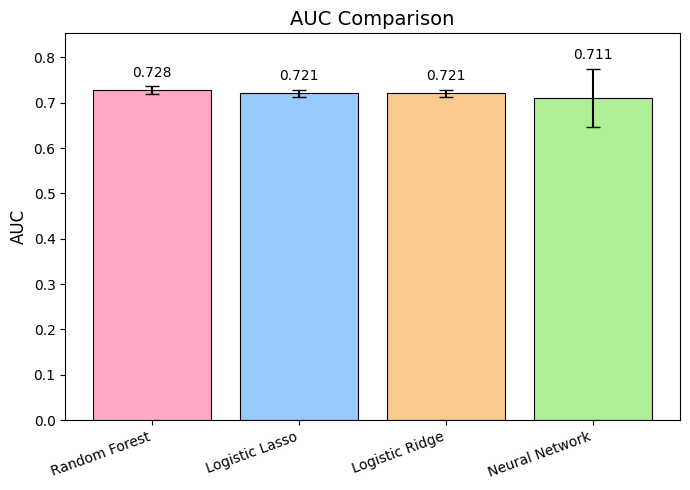

In [81]:
plot_metric(summary_df, "auc", "AUC")

Random Forest achieved the highest AUC, although the difference from the logistic regression models was relatively small. This suggests that all models possessed similar ability to rank patients according to mortality risk, with Random Forest providing only a modest improvement.

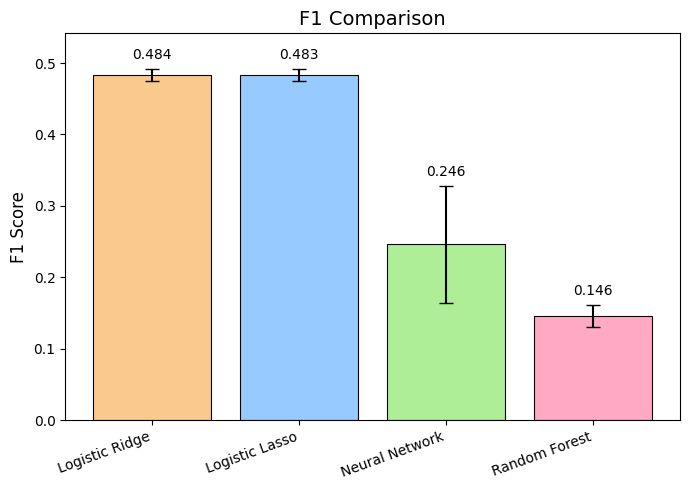

In [83]:
plot_metric(summary_df, "f1", "F1 Score")

Logistic Ridge and Logistic Lasso achieved the highest F1 scores, indicating a better balance between precision and recall. In contrast, Random Forest achieved high precision but low recall, resulting in a lower F1 score despite its superior AUC.

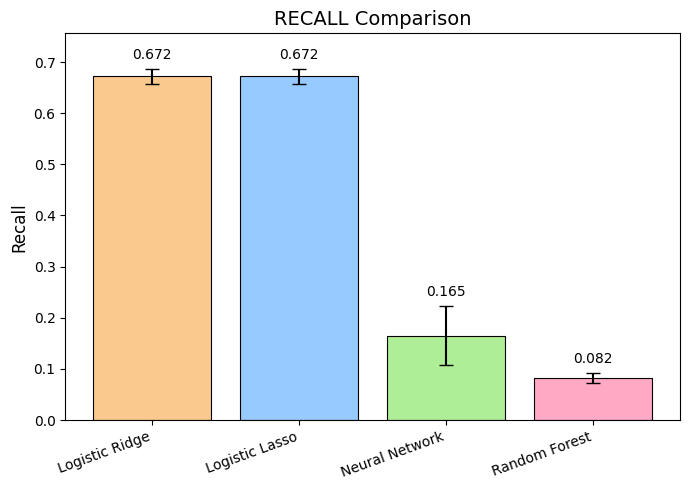

In [84]:
plot_metric(summary_df, "recall", "Recall")

Logistic Ridge and Logistic Lasso achieved substantially higher recall than Random Forest. Because the dataset contains relatively few mortality cases, recall is particularly important, as it measures the proportion of patients who died that were correctly identified. In clinical settings, failing to identify a high-risk patient may have more serious consequences than incorrectly identifying a survivor as high risk. Therefore, the higher recall of the logistic regression models may be preferable despite their slightly lower AUC.

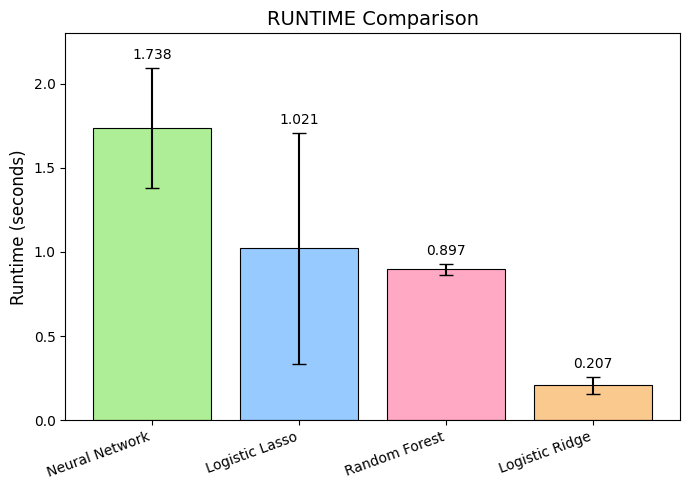

In [85]:
plot_metric(summary_df, "runtime", "Runtime (seconds)")

Logistic Ridge was the most computationally efficient model while also producing highly consistent runtimes across repeated experiments. Logistic Lasso required considerably more computation due to the optimization required for L1 regularization. Random Forest was the second fastest model on this dataset, likely because the number of predictors was relatively modest compared with the earlier simulation studies.

#### Conclusion about Model Performances

Overall, the models achieved comparable predictive performance, with AUC values ranging from approximately 0.72 to 0.75. Although differences existed across evaluation metrics, no single model consistently outperformed the others in every aspect. Instead, each model exhibited different strengths depending on the metric being considered.

Logistic Ridge and Logistic Lasso produced nearly identical predictive performance across all evaluation metrics. This suggests that replacing the L2 penalty with L1 regularization had little impact on this dataset. However, Ridge required substantially less computation time, making it the more efficient choice while maintaining comparable predictive performance.

Random Forest achieved the highest AUC, indicating that it ranked patients by mortality risk more effectively than the other models. It also achieved the highest precision, suggesting that patients predicted to die were more likely to actually experience the outcome. However, its substantially lower recall indicates that many patients who eventually died were not identified. Therefore, Random Forest appeared to favor precision over sensitivity.

The Neural Network demonstrated intermediate predictive performance but exhibited greater variability across repeated experiments than the other models. This is consistent with the stochastic optimization process used to train neural networks. Despite its greater flexibility, the Neural Network did not provide a clear performance advantage over the simpler logistic regression models.

An interesting observation is that the more flexible machine learning models did not substantially outperform the simpler logistic regression models. If strong nonlinear relationships were present in the predictor variables, one might expect Random Forest or Neural Networks to achieve noticeably better performance. Instead, only modest improvements in AUC were observed. This suggests that the available predictors either exhibit largely linear relationships with the outcome or that the available information limits predictive performance regardless of model complexity.

Considering predictive performance, computational efficiency, and stability, Logistic Ridge appears to provide the best overall balance for this dataset. Although Random Forest achieved the highest AUC, Logistic Ridge obtained substantially higher recall and F1 scores while requiring the shortest runtime. Given that mortality prediction prioritizes identifying high-risk patients, Logistic Ridge may be the more appropriate model for this application.

#### Important Predictors Identified by Each Model

In [86]:
lasso_coef = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso_balanced.coef_[0]
})

lasso_coef["Abs"] = lasso_coef["Coefficient"].abs()

lasso_coef = lasso_coef.sort_values("Abs", ascending=False)

lasso_coef.head(20)

,Feature,Coefficient,Abs
1,age,0.487992,0.487992
41,Shock_Index,0.250475,0.250475
2,elixhauser,0.225636,0.225636
40,mechvent,0.224949,0.224949
50,SOFA,0.200229,0.200229
18,BUN,0.193812,0.193812
35,paO2,-0.186337,0.186337
19,Creatinine,-0.183867,0.183867
45,input_total,-0.140717,0.140717
48,output_4hourly,-0.131203,0.131203


In [87]:
selected = lasso_coef[lasso_coef["Coefficient"] != 0]

print("Selected variables:", len(selected))
print(selected)

Selected variables: 53
             Feature  Coefficient       Abs
1                age     0.487992  0.487992
41       Shock_Index     0.250475  0.250475
2         elixhauser     0.225636  0.225636
40          mechvent     0.224949  0.224949
50              SOFA     0.200229  0.200229
18               BUN     0.193812  0.193812
35              paO2    -0.186337  0.186337
19        Creatinine    -0.183867  0.183867
45       input_total    -0.140717  0.140717
48    output_4hourly    -0.131203  0.131203
3       re_admission     0.131026  0.131026
28                Hb    -0.126981  0.126981
47      output_total     0.119621  0.119621
38  Arterial_lactate     0.116594  0.116594
6                 HR    -0.097996  0.097996
10                RR     0.090379  0.090379
0             gender    -0.089076  0.089076
51              SIRS     0.084450  0.084450
27           Albumin    -0.082330  0.082330
53          iv_input     0.079033  0.079033
29         WBC_count     0.069642  0.069642
33       

In [88]:
ridge_coef = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ridge_balanced.coef_[0]
})

ridge_coef["Abs"] = ridge_coef["Coefficient"].abs()

ridge_coef = ridge_coef.sort_values("Abs", ascending=False)

ridge_coef.head(20)

,Feature,Coefficient,Abs
45,input_total,-0.498648,0.498648
1,age,0.488406,0.488406
47,output_total,0.428553,0.428553
49,cumulated_balance,0.346041,0.346041
41,Shock_Index,0.263869,0.263869
2,elixhauser,0.226111,0.226111
40,mechvent,0.225607,0.225607
50,SOFA,0.200196,0.200196
18,BUN,0.194536,0.194536
35,paO2,-0.188746,0.188746


In [89]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": randomForest.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(20)

,Feature,Importance
1,age,0.046308
30,Platelets_count,0.029354
18,BUN,0.027212
12,Temp_C,0.026275
10,RR,0.025650
29,WBC_count,0.025303
41,Shock_Index,0.024680
42,PaO2_FiO2,0.024373
31,PTT,0.023593
35,paO2,0.023545


In [90]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    nn2,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

nn_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": result.importances_mean
})

nn_importance = nn_importance.sort_values(
    "Importance",
    ascending=False
)

nn_importance.head(20)

,Feature,Importance
45,input_total,0.009179
25,SGPT,0.002549
26,Total_bili,0.001758
24,SGOT,0.000743
29,WBC_count,0.000700
39,HCO3,0.000635
4,Weight_kg,0.000625
8,MeanBP,0.000450
36,paCO2,0.000420
5,GCS,0.000316


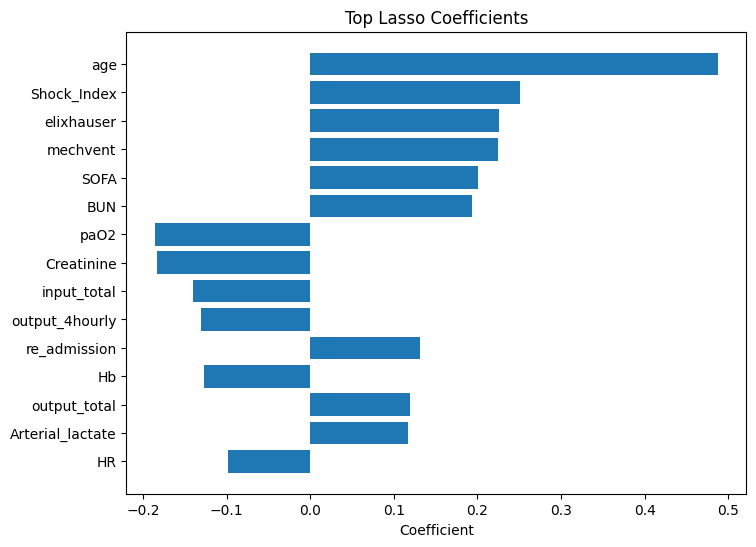

In [93]:
top = lasso_coef.head(15)

plt.figure(figsize=(8,6))
plt.barh(top["Feature"], top["Coefficient"])
plt.gca().invert_yaxis()

plt.xlabel("Coefficient")
plt.title("Top Lasso Coefficients")
plt.show()

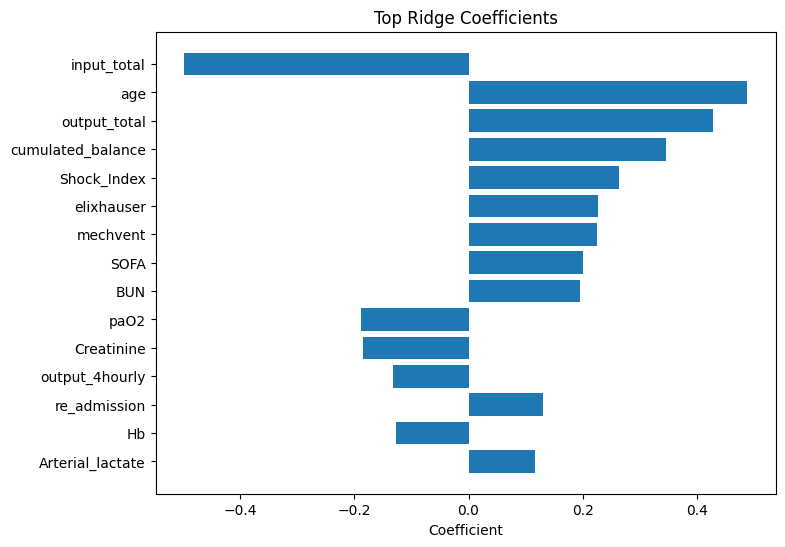

In [91]:
top = ridge_coef.head(15)

plt.figure(figsize=(8,6))
plt.barh(top["Feature"], top["Coefficient"])
plt.gca().invert_yaxis()

plt.xlabel("Coefficient")
plt.title("Top Ridge Coefficients")
plt.show()

In [ ]:
top = rf_importance.head(15)

plt.figure(figsize=(8,6))
plt.barh(top["Feature"], top["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

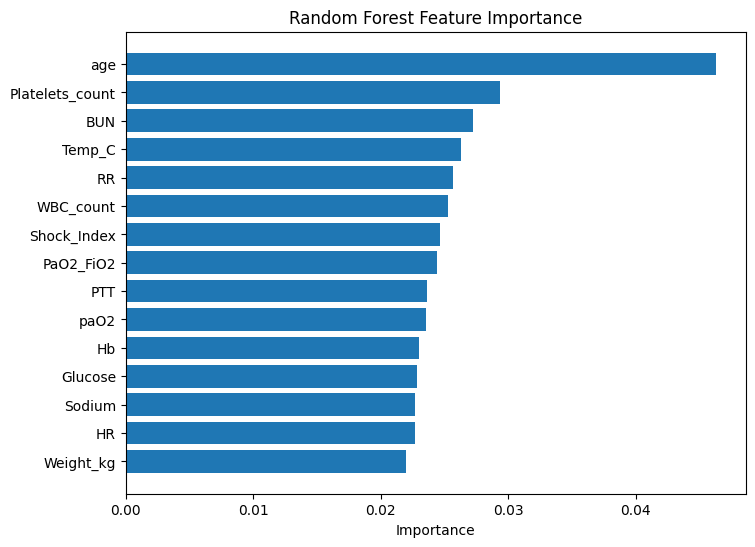

In [94]:
top = rf_importance.head(15)

plt.figure(figsize=(8,6))
plt.barh(top["Feature"], top["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

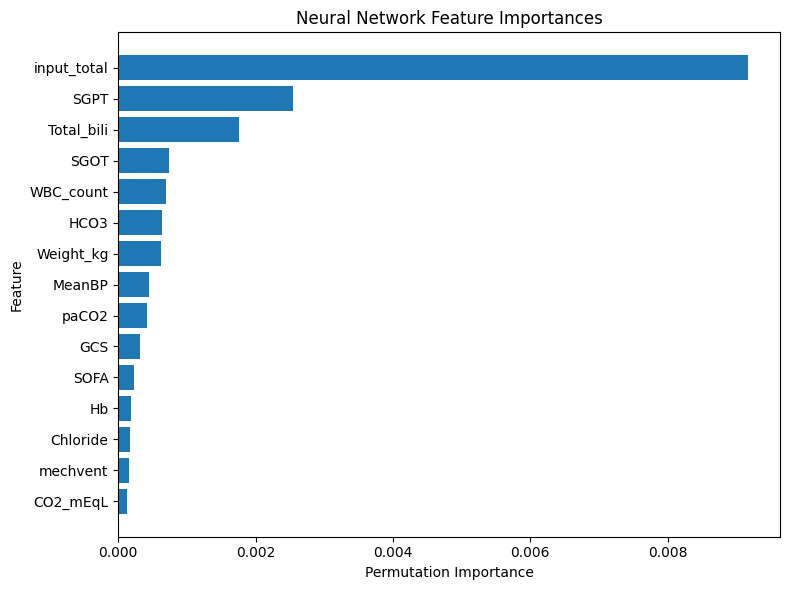

In [99]:
# Top 15 important features
top = nn_importance.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top["Feature"], top["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Neural Network Feature Importances")

plt.tight_layout()
plt.show()

Feature importance was examined to identify the predictors driving each model's predictions. Across the models, age was consistently one of the most influential predictors, while clinical severity measures such as Shock Index, SOFA, BUN, Creatinine, and mechanical ventilation also appeared frequently. Lasso and Ridge identified similar important variables, whereas Random Forest emphasized additional laboratory and vital sign measurements, reflecting its ability to model nonlinear relationships. The neural network showed a stronger dependence on input_total, suggesting a different pattern of feature utilization.